In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df=pd.read_excel("Disease_Prediction_Health_Dataset.xlsx")

In [9]:
!pip install openpyxl


In [7]:
df = pd.read_excel("Disease_Prediction_Health_Dataset.xlsx")


In [10]:
df.head()

,Age,Gender,BMI,Blood_Pressure_mmHg,Cholesterol_mg_dL,Glucose_mg_dL,Heart_Rate_bpm,Smoking,Exercise_Level,Disease
0,56,Male,26.6,140,277,75,55,No,Moderate,Disease
1,69,Male,29.8,165,215,115,61,No,Low,No Disease
2,46,Male,24.1,128,189,77,50,No,Low,No Disease
3,32,Male,31.8,101,185,120,90,No,Moderate,No Disease
4,60,Male,27.0,170,201,122,76,Yes,Moderate,Disease


In [11]:
df.tail()

,Age,Gender,BMI,Blood_Pressure_mmHg,Cholesterol_mg_dL,Glucose_mg_dL,Heart_Rate_bpm,Smoking,Exercise_Level,Disease
2995,68,Female,32.6,165,227,77,76,No,Low,No Disease
2996,32,Male,25.4,126,159,140,78,No,Moderate,No Disease
2997,21,Male,28.9,112,176,108,67,No,Low,No Disease
2998,38,Female,32.6,110,223,100,72,No,High,No Disease
2999,30,Female,24.6,125,179,127,60,Yes,High,No Disease


In [13]:
df.shape

(3000, 10)

In [14]:
df.columns

Index(['Age', 'Gender', 'BMI', 'Blood_Pressure_mmHg', 'Cholesterol_mg_dL',
       'Glucose_mg_dL', 'Heart_Rate_bpm', 'Smoking', 'Exercise_Level',
       'Disease'],
      dtype='str')

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  3000 non-null   int64  
 1   Gender               3000 non-null   str    
 2   BMI                  3000 non-null   float64
 3   Blood_Pressure_mmHg  3000 non-null   int64  
 4   Cholesterol_mg_dL    3000 non-null   int64  
 5   Glucose_mg_dL        3000 non-null   int64  
 6   Heart_Rate_bpm       3000 non-null   int64  
 7   Smoking              3000 non-null   str    
 8   Exercise_Level       3000 non-null   str    
 9   Disease              3000 non-null   str    
dtypes: float64(1), int64(5), str(4)
memory usage: 298.9 KB


In [16]:
df.describe()

,Age,BMI,Blood_Pressure_mmHg,Cholesterol_mg_dL,Glucose_mg_dL,Heart_Rate_bpm
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000
mean,49.446667,25.363333,132.236333,204.623000,108.447667,72.62600
std,18.207572,4.676400,19.317493,32.902245,24.384492,9.92201
min,18.000000,16.000000,90.000000,120.000000,65.000000,50.00000
25%,34.000000,22.100000,118.000000,182.000000,91.000000,66.00000
50%,50.000000,25.350000,132.000000,205.000000,108.500000,73.00000
75%,65.000000,28.600000,146.000000,227.000000,125.000000,79.00000
max,80.000000,41.100000,180.000000,311.000000,194.000000,118.00000


In [17]:
df.dtypes

Age                      int64
Gender                     str
BMI                    float64
Blood_Pressure_mmHg      int64
Cholesterol_mg_dL        int64
Glucose_mg_dL            int64
Heart_Rate_bpm           int64
Smoking                    str
Exercise_Level             str
Disease                    str
dtype: object

In [18]:
df.isnull().sum()

Age                    0
Gender                 0
BMI                    0
Blood_Pressure_mmHg    0
Cholesterol_mg_dL      0
Glucose_mg_dL          0
Heart_Rate_bpm         0
Smoking                0
Exercise_Level         0
Disease                0
dtype: int64

In [19]:
(df.isnull().sum()/len(df))*100

Age                    0.0
Gender                 0.0
BMI                    0.0
Blood_Pressure_mmHg    0.0
Cholesterol_mg_dL      0.0
Glucose_mg_dL          0.0
Heart_Rate_bpm         0.0
Smoking                0.0
Exercise_Level         0.0
Disease                0.0
dtype: float64

In [20]:
df.duplicated().sum()

np.int64(0)

In [22]:
df[df.duplicated()]

,Age,Gender,BMI,Blood_Pressure_mmHg,Cholesterol_mg_dL,Glucose_mg_dL,Heart_Rate_bpm,Smoking,Exercise_Level,Disease


In [23]:
df = df.drop_duplicates()

In [24]:
df.duplicated().sum()

np.int64(0)

0
Disease
No Disease    0.766
Disease       0.234
Name: proportion, dtype: float64
                  Age        BMI  Blood_Pressure_mmHg  Cholesterol_mg_dL  \
Disease                                                                    
Disease     65.188034  27.419943           149.270655         225.398860   
No Disease  44.637946  24.735074           127.032637         198.276327   

            Glucose_mg_dL  Heart_Rate_bpm  
Disease                                    
Disease        122.663818       73.455840  
No Disease     104.104874       72.372498  


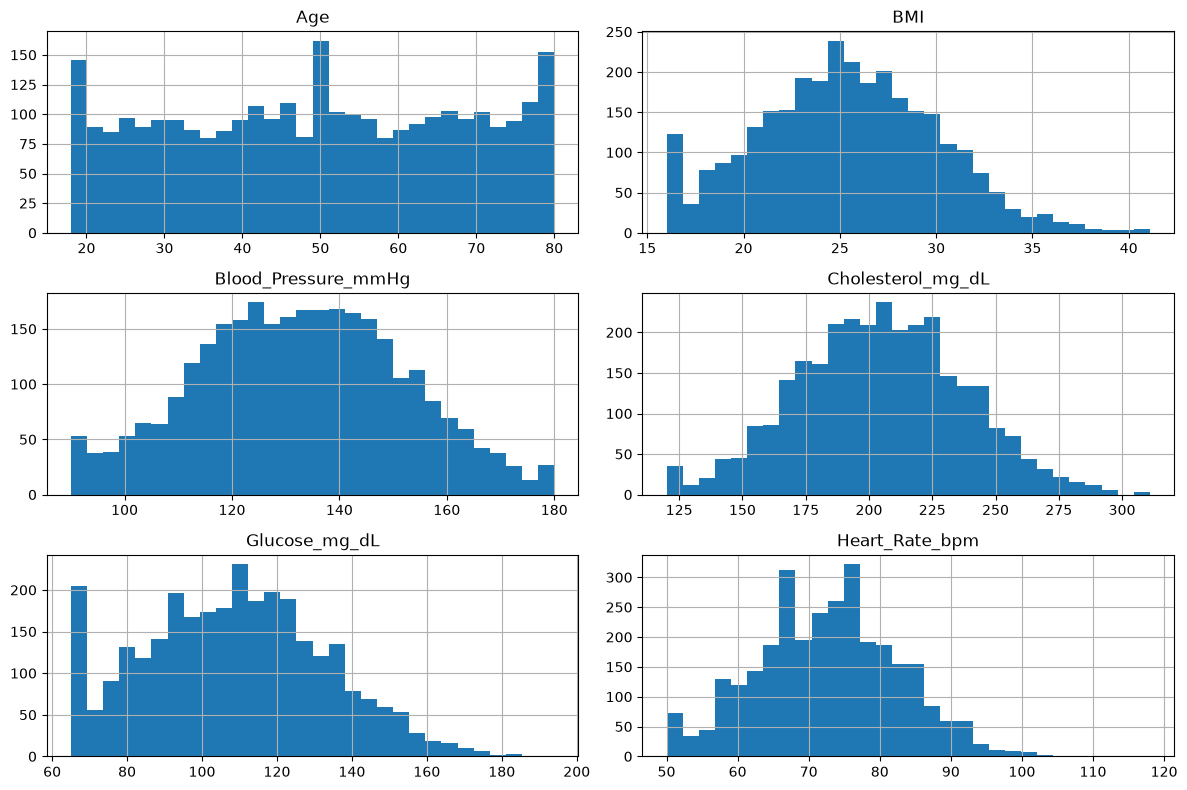

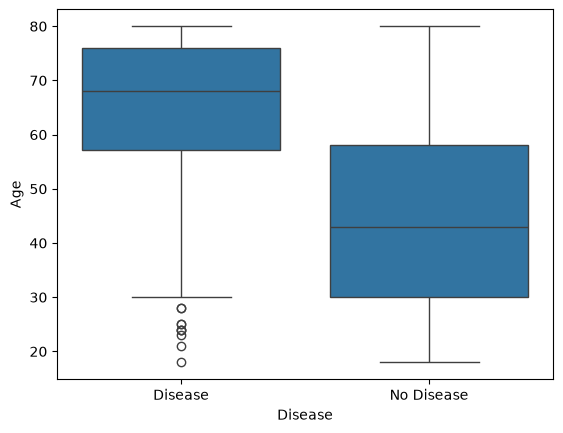

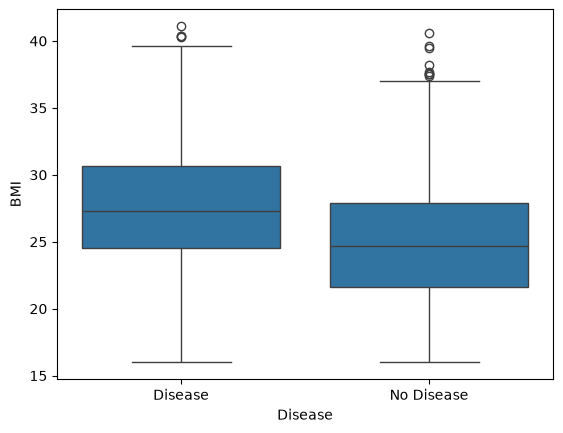

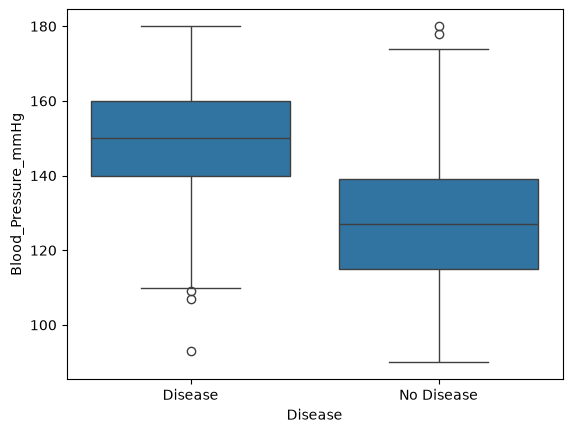

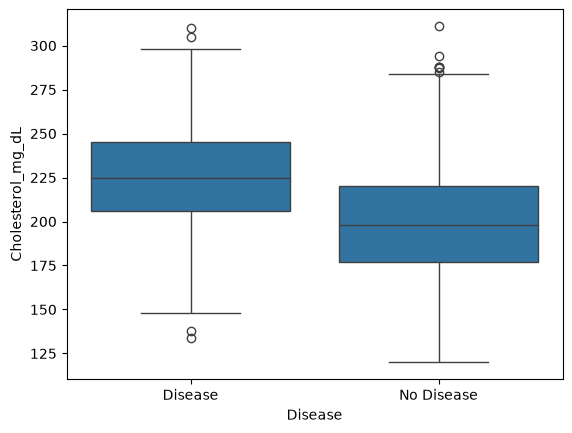

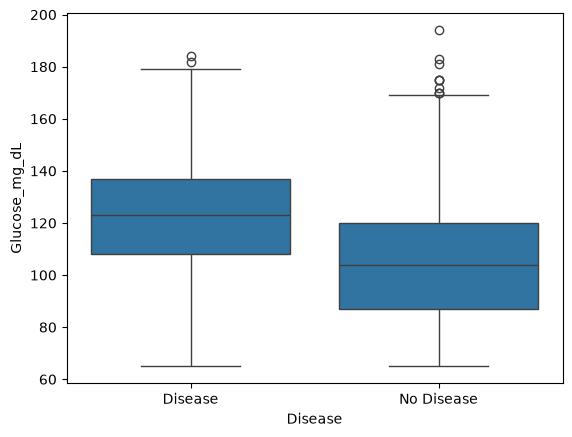

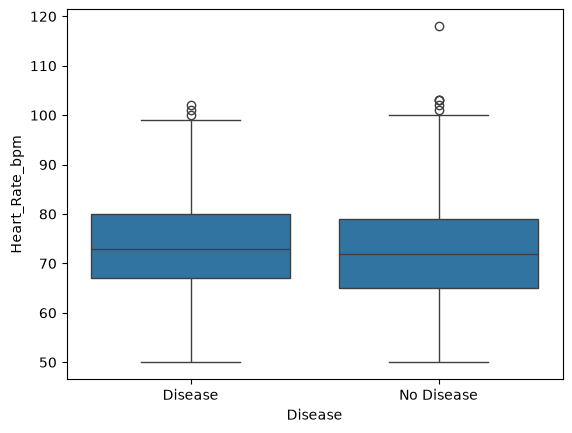

Disease   Disease  No Disease
Gender                       
Female   0.226349    0.773651
Male     0.240941    0.759059
Disease   Disease  No Disease
Smoking                      
No       0.230982    0.769018
Yes      0.241877    0.758123
Disease          Disease  No Disease
Exercise_Level                      
High            0.220000    0.780000
Low             0.246563    0.753437
Moderate        0.229581    0.770419


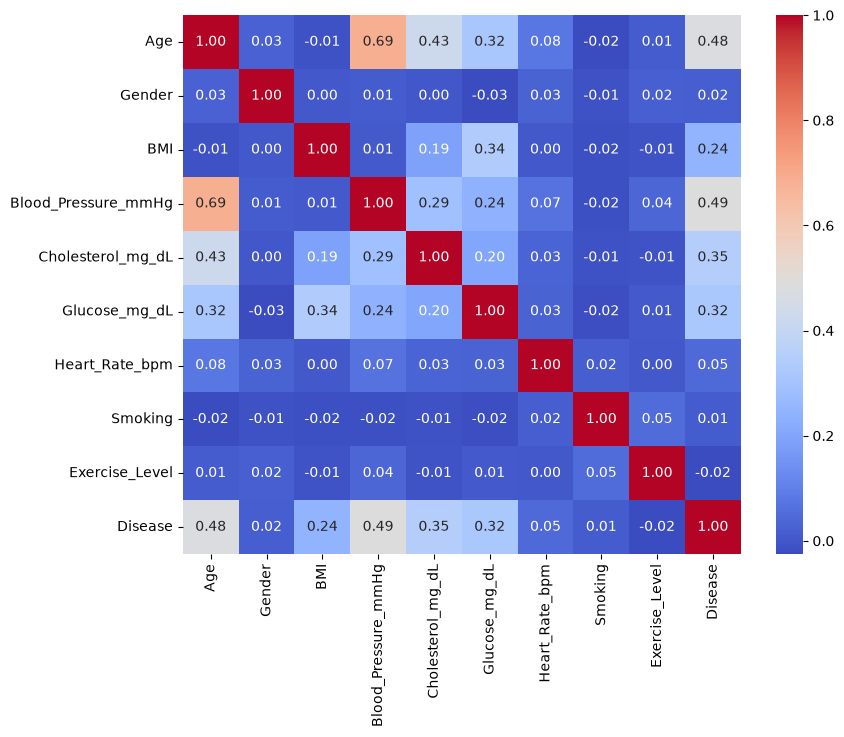

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ["Age", "BMI", "Blood_Pressure_mmHg", "Cholesterol_mg_dL",
            "Glucose_mg_dL", "Heart_Rate_bpm"]

# 1. Duplicates and class balance
print(df.duplicated().sum())
print(df["Disease"].value_counts(normalize=True))

# 2. How each numeric feature differs by class
print(df.groupby("Disease")[num_cols].mean())

# 3. Distributions
df[num_cols].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

for c in num_cols:
    sns.boxplot(data=df, x="Disease", y=c)
    plt.show()

# 4. Categorical features vs disease rate
for c in ["Gender", "Smoking", "Exercise_Level"]:
    print(pd.crosstab(df[c], df["Disease"], normalize="index"))

# 5. Encode, then correlation heatmap
df_enc = df.copy()
df_enc["Gender"] = df_enc["Gender"].map({"Female": 0, "Male": 1})
df_enc["Smoking"] = df_enc["Smoking"].map({"No": 0, "Yes": 1})
df_enc["Exercise_Level"] = df_enc["Exercise_Level"].map({"Low": 0, "Moderate": 1, "High": 2})
df_enc["Disease"] = df_enc["Disease"].map({"No Disease": 0, "Disease": 1})

plt.figure(figsize=(9, 7))
sns.heatmap(df_enc.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [29]:
from sklearn.model_selection import train_test_split

X = df_enc.drop("Disease", axis=1)
y = df_enc["Disease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print(X_train.shape, X_test.shape)

(2400, 9) (600, 9)


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [31]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
model.fit(X_train_s, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to u

In [32]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

pred = model.predict(X_test_s)
proba = model.predict_proba(X_test_s)[:, 1]

print("Train acc:", round(model.score(X_train_s, y_train), 3),
      "| Test acc:", round(model.score(X_test_s, y_test), 3))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, target_names=["No Disease", "Disease"]))
print("ROC-AUC:", round(roc_auc_score(y_test, proba), 3))

Train acc: 0.813 | Test acc: 0.823
[[375  85]
 [ 21 119]]
              precision    recall  f1-score   support

  No Disease       0.95      0.82      0.88       460
     Disease       0.58      0.85      0.69       140

    accuracy                           0.82       600
   macro avg       0.77      0.83      0.78       600
weighted avg       0.86      0.82      0.83       600

ROC-AUC: 0.912


In [33]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

pred = model.predict(X_test_s)
proba = model.predict_proba(X_test_s)[:, 1]

print("Train acc:", round(model.score(X_train_s, y_train), 3),
      "| Test acc:", round(model.score(X_test_s, y_test), 3))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, target_names=["No Disease", "Disease"]))
print("ROC-AUC:", round(roc_auc_score(y_test, proba), 3))

Train acc: 0.813 | Test acc: 0.823
[[375  85]
 [ 21 119]]
              precision    recall  f1-score   support

  No Disease       0.95      0.82      0.88       460
     Disease       0.58      0.85      0.69       140

    accuracy                           0.82       600
   macro avg       0.77      0.83      0.78       600
weighted avg       0.86      0.82      0.83       600

ROC-AUC: 0.912


In [34]:
import numpy as np, pandas as pd

coef = pd.Series(model.coef_[0], index=X.columns)
print(pd.DataFrame({"coef": coef, "odds_ratio": np.exp(coef)})
      .sort_values("coef", ascending=False).round(3))

                      coef  odds_ratio
Blood_Pressure_mmHg  1.172       3.230
Age                  0.807       2.240
BMI                  0.724       2.063
Cholesterol_mg_dL    0.520       1.683
Glucose_mg_dL        0.444       1.559
Smoking              0.119       1.127
Heart_Rate_bpm       0.033       1.034
Gender              -0.081       0.922
Exercise_Level      -0.226       0.798


In [35]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(5, shuffle=True, random_state=42)
subsets = {
    "All 9 features": list(X.columns),
    "Drop Gender/Smoking/HeartRate": ["Age", "BMI", "Blood_Pressure_mmHg",
                                      "Cholesterol_mg_dL", "Glucose_mg_dL", "Exercise_Level"],
}
for name, cols in subsets.items():
    Xs = StandardScaler().fit_transform(X_train[cols])
    f1 = cross_val_score(LogisticRegression(class_weight="balanced", max_iter=1000),
                         Xs, y_train, cv=cv, scoring="f1").mean()
    print(name, round(f1, 3))

All 9 features 0.674
Drop Gender/Smoking/HeartRate 0.677


In [36]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

dt0 = DecisionTreeClassifier(class_weight="balanced", random_state=42)
dt0.fit(X_train, y_train)

print("Depth:", dt0.get_depth(), "| Leaves:", dt0.get_n_leaves())
print("Train acc:", round(dt0.score(X_train, y_train), 3),
      "| Test acc:", round(dt0.score(X_test, y_test), 3))
print("Test ROC-AUC:", round(roc_auc_score(y_test, dt0.predict_proba(X_test)[:, 1]), 3))

Depth: 20 | Leaves: 374
Train acc: 1.0 | Test acc: 0.798
Test ROC-AUC: 0.717


In [37]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(5, shuffle=True, random_state=42)
grid = GridSearchCV(
    DecisionTreeClassifier(class_weight="balanced", random_state=42),
    {"max_depth": [2, 3, 4, 5, 6, 8],
     "min_samples_leaf": [5, 10, 20, 40],
     "criterion": ["gini", "entropy"]},
    scoring="f1", cv=cv, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best:", grid.best_params_, "| CV F1:", round(grid.best_score_, 3))
dt = grid.best_estimator_

Best: {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 5} | CV F1: 0.629


In [38]:
pred = dt.predict(X_test)
proba = dt.predict_proba(X_test)[:, 1]

print("Train acc:", round(dt.score(X_train, y_train), 3),
      "| Test acc:", round(dt.score(X_test, y_test), 3))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, target_names=["No Disease", "Disease"]))
print("ROC-AUC:", round(roc_auc_score(y_test, proba), 3))

Train acc: 0.82 | Test acc: 0.793
[[361  99]
 [ 25 115]]
              precision    recall  f1-score   support

  No Disease       0.94      0.78      0.85       460
     Disease       0.54      0.82      0.65       140

    accuracy                           0.79       600
   macro avg       0.74      0.80      0.75       600
weighted avg       0.84      0.79      0.81       600

ROC-AUC: 0.857


Blood_Pressure_mmHg    0.514
Age                    0.165
BMI                    0.138
Glucose_mg_dL          0.091
Cholesterol_mg_dL      0.060
Heart_Rate_bpm         0.030
Gender                 0.003
Smoking                0.000
Exercise_Level         0.000
dtype: float64


<Axes: title={'center': 'Decision Tree feature importance'}>

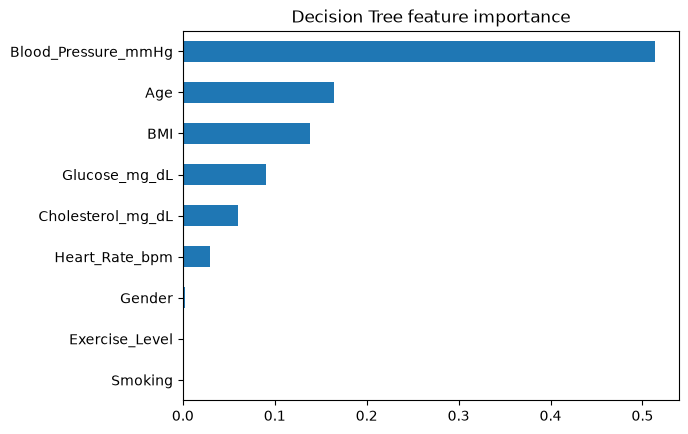

In [39]:
import pandas as pd
imp = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)
print(imp.round(3))
imp.sort_values().plot.barh(title="Decision Tree feature importance")


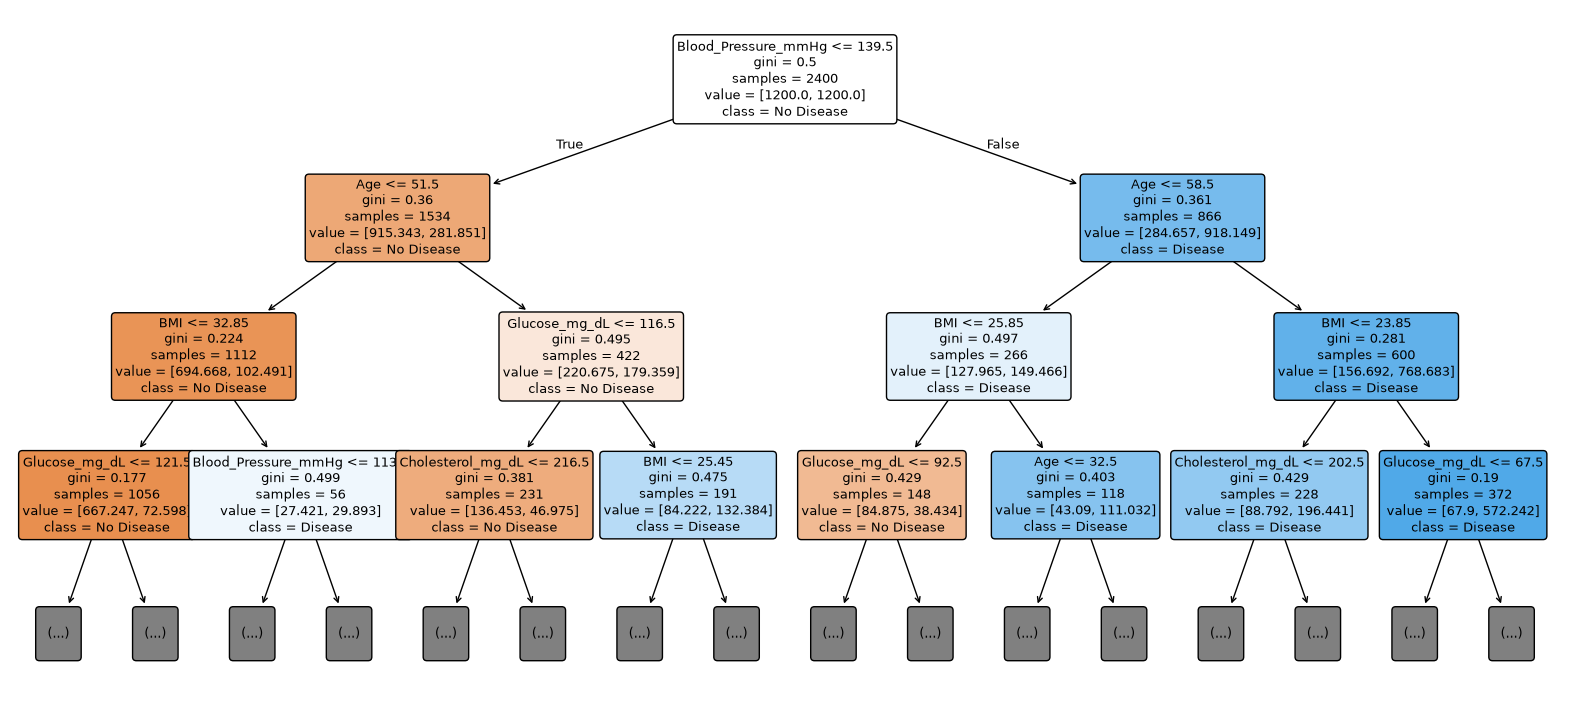

In [40]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 9))
plot_tree(dt, feature_names=X.columns, class_names=["No Disease", "Disease"],
          filled=True, rounded=True, fontsize=9, max_depth=3)
plt.show()

In [41]:
import pandas as pd, numpy as np, joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV

RS = 42
y = (df["Disease"] == "Disease").astype(int)
X = df.drop(columns="Disease")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RS)
print(X_train.shape, X_test.shape)

(2400, 9) (600, 9)


In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

num = ["Age", "BMI", "Blood_Pressure_mmHg", "Cholesterol_mg_dL", "Glucose_mg_dL", "Heart_Rate_bpm"]
prep = ColumnTransformer([
    ("num", StandardScaler(), num),
    ("bin", OrdinalEncoder(categories=[["Female", "Male"], ["No", "Yes"]]), ["Gender", "Smoking"]),
    ("ord", OrdinalEncoder(categories=[["Low", "Moderate", "High"]]), ["Exercise_Level"]),
])
cv = StratifiedKFold(5, shuffle=True, random_state=RS)

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([("prep", prep),
                 ("clf", LogisticRegression(class_weight="balanced", max_iter=2000))])
grid = GridSearchCV(pipe, {"clf__C": [0.01, 0.1, 1, 10, 100],
                           "clf__solver": ["lbfgs", "liblinear"]},
                    scoring="average_precision", cv=cv, n_jobs=-1)
grid.fit(X_train, y_train)
best = grid.best_estimator_
print("Best parameters:", grid.best_params_, "| CV PR-AUC:", round(grid.best_score_, 3))

Best parameters: {'clf__C': 0.1, 'clf__solver': 'lbfgs'} | CV PR-AUC: 0.764


In [44]:
from sklearn.metrics import classification_report, roc_auc_score

THRESHOLD = 0.5
proba = best.predict_proba(X_test)[:, 1]
pred = (proba >= THRESHOLD).astype(int)
print(classification_report(y_test, pred, target_names=["No Disease", "Disease"]))
print("ROC-AUC:", round(roc_auc_score(y_test, proba), 3))

              precision    recall  f1-score   support

  No Disease       0.95      0.81      0.87       460
     Disease       0.57      0.85      0.69       140

    accuracy                           0.82       600
   macro avg       0.76      0.83      0.78       600
weighted avg       0.86      0.82      0.83       600

ROC-AUC: 0.912


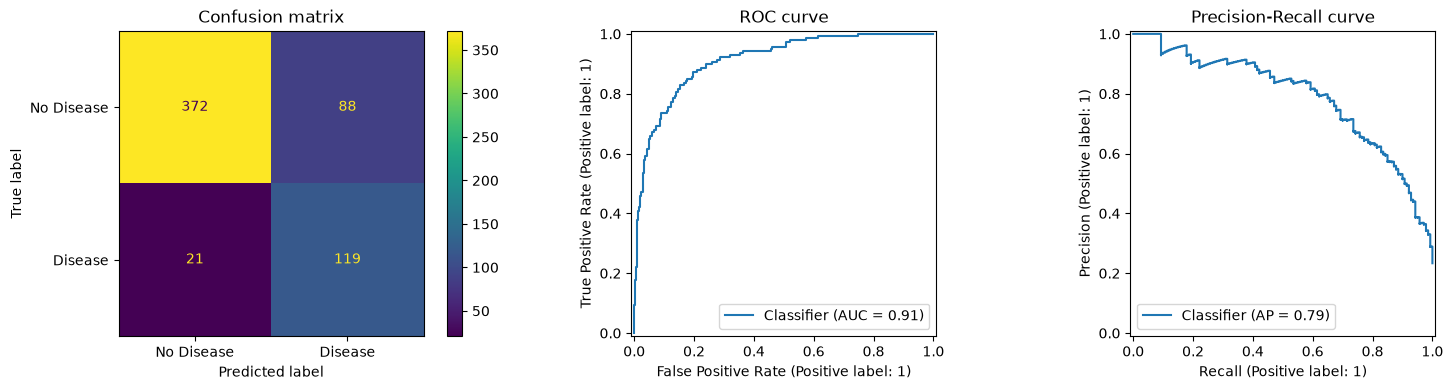

In [45]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["No Disease", "Disease"], ax=ax[0])
RocCurveDisplay.from_predictions(y_test, proba, ax=ax[1])
PrecisionRecallDisplay.from_predictions(y_test, proba, ax=ax[2])
ax[0].set_title("Confusion matrix"); ax[1].set_title("ROC curve"); ax[2].set_title("Precision-Recall curve")
plt.tight_layout(); plt.show()

                     coefficient  odds_ratio
Blood_Pressure_mmHg        1.107       3.025
Age                        0.784       2.189
BMI                        0.683       1.980
Cholesterol_mg_dL          0.505       1.656
Glucose_mg_dL              0.434       1.543
Smoking                    0.220       1.246
Heart_Rate_bpm             0.032       1.033
Gender                    -0.137       0.872
Exercise_Level            -0.285       0.752


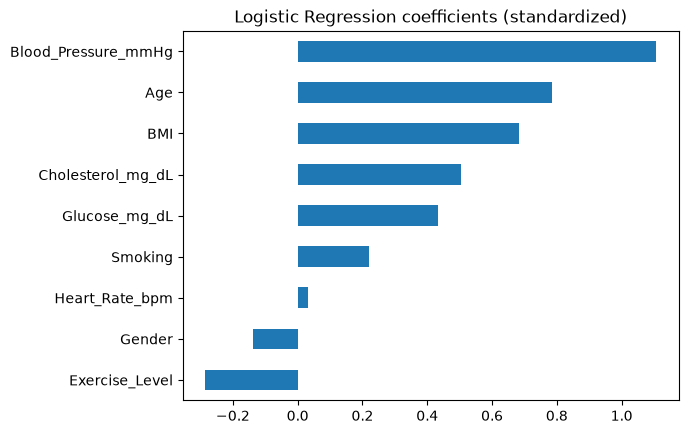

In [46]:
names = num + ["Gender", "Smoking", "Exercise_Level"]
coef = pd.Series(best.named_steps["clf"].coef_[0], index=names)
print(pd.DataFrame({"coefficient": coef, "odds_ratio": np.exp(coef)})
      .sort_values("odds_ratio", ascending=False).round(3))
coef.sort_values().plot.barh(title="Logistic Regression coefficients (standardized)")
plt.show()

In [47]:
joblib.dump({"model": best, "threshold": THRESHOLD}, "disease_model.joblib")

new = pd.DataFrame([{"Age": 55, "Gender": "Male", "BMI": 28.0, "Blood_Pressure_mmHg": 150,
                     "Cholesterol_mg_dL": 230, "Glucose_mg_dL": 120, "Heart_Rate_bpm": 75,
                     "Smoking": "Yes", "Exercise_Level": "Low"}])
p = best.predict_proba(new)[0, 1]
print(f"Estimated risk: {p:.0%} ->", "Disease likely" if p >= THRESHOLD else "Low risk")

Estimated risk: 83% -> Disease likely


In [48]:
low = pd.DataFrame([{"Age": 30, "Gender": "Female", "BMI": 22.0, "Blood_Pressure_mmHg": 110,
                     "Cholesterol_mg_dL": 170, "Glucose_mg_dL": 90, "Heart_Rate_bpm": 68,
                     "Smoking": "No", "Exercise_Level": "High"}])
p = best.predict_proba(low)[0, 1]
print(f"Estimated risk: {p:.0%} ->", "Disease likely" if p >= THRESHOLD else "Low risk")

Estimated risk: 1% -> Low risk


In [4]:
%pip install ipywidgets

   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.2 MB 2.5 MB/s eta 0:00:01
   -------------- ------------------------- 0.8/2.2 MB 2.3 MB/s eta 0:00:01
   ---------------------------- ----------- 1.6/2.2 MB 2.3 MB/s eta 0:00:01
   ------------------------------------- -- 2.1/2.2 MB 2.4 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 2.3 MB/s  0:00:00

   ---------------------------------------- 0/3 [widgetsnbextension]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidge